# Data Preprocessing

The dataset is loaded and inspected to understand its structure and data types.  
The identifier column is removed as it has no predictive value.  
Age is converted from days to years to improve interpretability.  
Binary variables are cast to integer format for modeling consistency.  
Invalid and unrealistic blood pressure values are removed using physiological constraints.  
Extreme and biologically implausible height and weight values are filtered out.  
Body Mass Index (BMI) is computed as an additional medically relevant feature.  

After preprocessing, the dataset is clean and ready for exploratory analysis and modeling.


In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Load the cardiovascular dataset
# NOTE: The file uses ';' as a separator
df = pd.read_csv("cardio_train.csv", sep=";")

# Preview the data
df.head()


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
# Check dataset size and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [4]:
# The 'id' column is only an identifier
# It has no predictive power for machine learning
df = df.drop(columns=["id"])


In [5]:
# Age is stored in days
# Convert it to years for better interpretability
df["age_years"] = df["age"] / 365.25

# Remove original age column
df = df.drop(columns=["age"])

df["age_years"].describe()


,age_years
count,70000.000000
mean,53.302850
std,6.754967
min,29.563313
25%,48.361396
50%,53.943874
75%,58.390144
max,64.922656


In [6]:
# Ensure binary columns are integers (0 or 1)
binary_columns = ["smoke", "alco", "active", "cardio"]

for col in binary_columns:
    df[col] = df[col].astype(int)

df.dtypes


,0
gender,int64
height,int64
weight,float64
ap_hi,int64
ap_lo,int64
cholesterol,int64
gluc,int64
smoke,int64
alco,int64
active,int64


In [7]:
# Remove impossible or incorrect blood pressure values
# Rules applied:
# 1. Blood pressure must be positive
# 2. Upper limits for realistic human values
# 3. Systolic pressure must be higher than diastolic pressure

df = df[(df["ap_hi"] > 0) & (df["ap_lo"] > 0)]
df = df[(df["ap_hi"] < 300) & (df["ap_lo"] < 200)]
df = df[df["ap_hi"] > df["ap_lo"]]


In [8]:
# Remove unrealistic height and weight values
df = df[(df["height"] >= 120) & (df["height"] <= 220)]
df = df[(df["weight"] >= 30) & (df["weight"] <= 200)]


In [9]:
# Calculate Body Mass Index (BMI)
df["bmi"] = df["weight"] / ((df["height"] / 100) ** 2)

df["bmi"].describe()


,bmi
count,68652.000000
mean,27.457073
std,5.257117
min,10.726644
25%,23.875115
50%,26.346494
75%,30.116213
max,108.169847


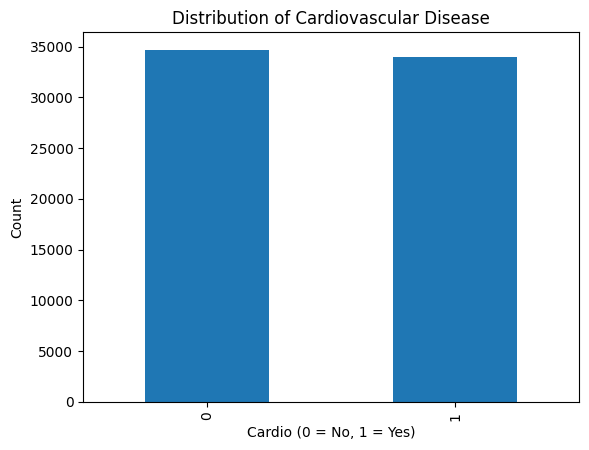

In [10]:
import matplotlib.pyplot as plt

# Distribution of cardiovascular disease cases
df["cardio"].value_counts().plot(kind="bar")
plt.title("Distribution of Cardiovascular Disease")
plt.xlabel("Cardio (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


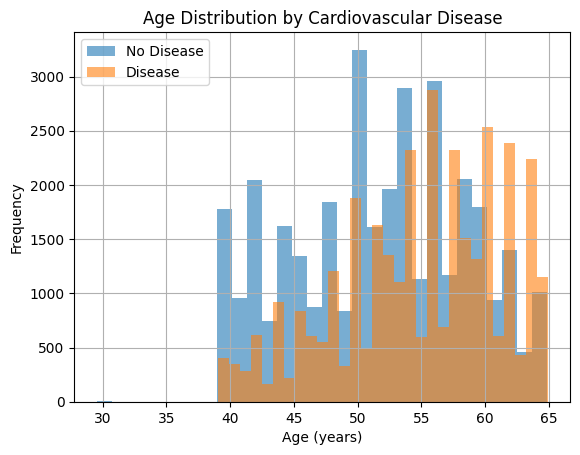

In [11]:
# Age distribution separated by cardiovascular disease
plt.figure()
df[df["cardio"] == 0]["age_years"].hist(alpha=0.6, bins=30)
df[df["cardio"] == 1]["age_years"].hist(alpha=0.6, bins=30)
plt.title("Age Distribution by Cardiovascular Disease")
plt.xlabel("Age (years)")
plt.ylabel("Frequency")
plt.legend(["No Disease", "Disease"])
plt.show()


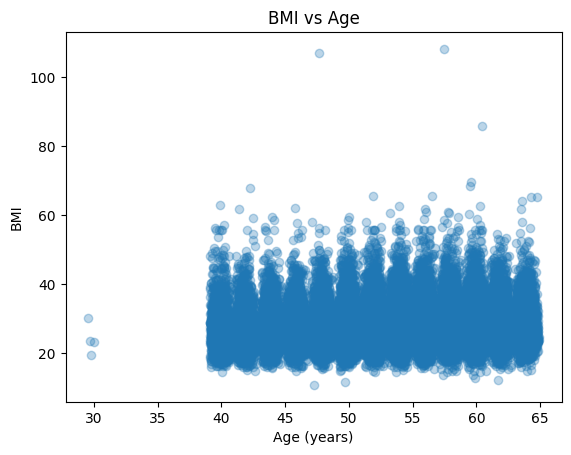

In [12]:
# Relationship between age and BMI
plt.figure()
plt.scatter(df["age_years"], df["bmi"], alpha=0.3)
plt.title("BMI vs Age")
plt.xlabel("Age (years)")
plt.ylabel("BMI")
plt.show()


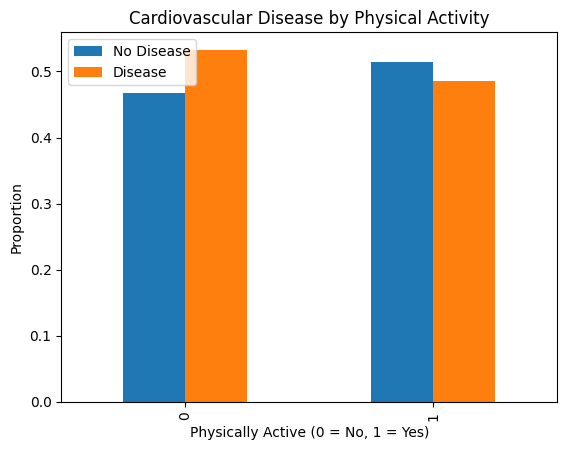

In [13]:
# Proportion of cardiovascular disease by physical activity level
pd.crosstab(df["active"], df["cardio"], normalize="index").plot(kind="bar")
plt.title("Cardiovascular Disease by Physical Activity")
plt.xlabel("Physically Active (0 = No, 1 = Yes)")
plt.ylabel("Proportion")
plt.legend(["No Disease", "Disease"])
plt.show()

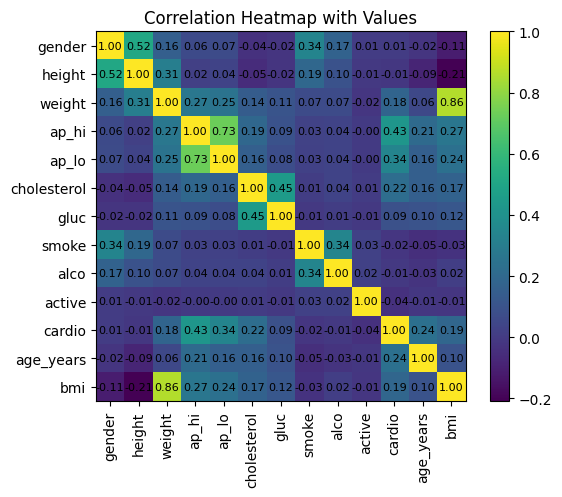

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Compute correlation matrix
corr = df.corr()

# Create heatmap
plt.figure()
plt.imshow(corr)
plt.colorbar()

# Add axis labels
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

# Add correlation values inside the heatmap
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center", fontsize=8)

plt.title("Correlation Heatmap with Values")
plt.show()


## Model Building

After preprocessing and exploratory data analysis, machine learning models are trained
to predict the presence of cardiovascular disease. A baseline model is first implemented
to establish a reference performance.


In [15]:
# Separate features and target variable
X = df.drop(columns=["cardio"])
y = df["cardio"]


In [16]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [17]:
from sklearn.preprocessing import StandardScaler

numeric_columns = ["age_years", "height", "weight", "ap_hi", "ap_lo", "bmi"]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_test_scaled[numeric_columns] = scaler.transform(X_test[numeric_columns])


## Advanced Machine Learning Models

After establishing a baseline model, more advanced machine learning algorithms are applied
to improve predictive performance. Random Forest, Support Vector Machine (SVM), and XGBoost
are used and evaluated on the same train-test split for fair comparison.


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.7035904158473527
              precision    recall  f1-score   support

           0       0.70      0.72      0.71      6938
           1       0.71      0.68      0.70      6793

    accuracy                           0.70     13731
   macro avg       0.70      0.70      0.70     13731
weighted avg       0.70      0.70      0.70     13731



In [19]:
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf", random_state=42)

svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))


SVM Accuracy: 0.7271866579273177
              precision    recall  f1-score   support

           0       0.71      0.79      0.75      6938
           1       0.76      0.66      0.71      6793

    accuracy                           0.73     13731
   macro avg       0.73      0.73      0.73     13731
weighted avg       0.73      0.73      0.73     13731



In [20]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))


XGBoost Accuracy: 0.7268225183890467
              precision    recall  f1-score   support

           0       0.71      0.78      0.74      6938
           1       0.75      0.67      0.71      6793

    accuracy                           0.73     13731
   macro avg       0.73      0.73      0.73     13731
weighted avg       0.73      0.73      0.73     13731



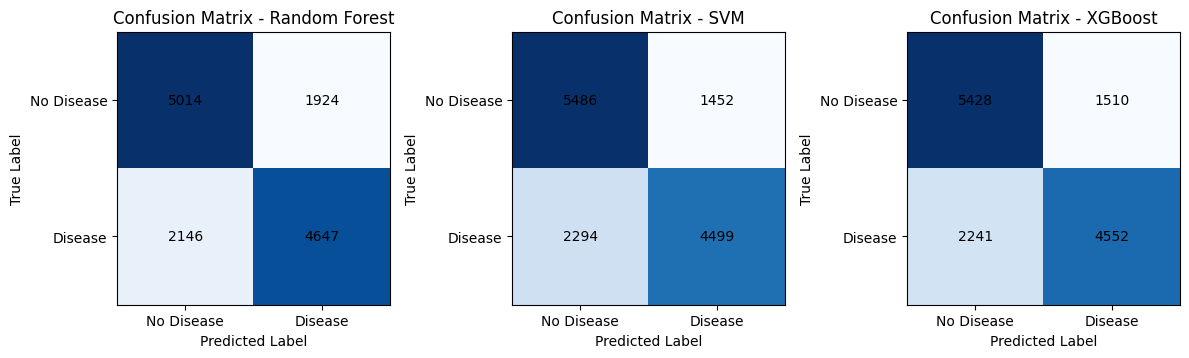

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrices
cm_rf = confusion_matrix(y_test, rf_pred)
cm_svm = confusion_matrix(y_test, svm_pred)
cm_xgb = confusion_matrix(y_test, xgb_pred)

# Plot confusion matrices in one row
plt.figure(figsize=(12, 4))

conf_matrices = [cm_rf, cm_svm, cm_xgb]
model_names = ["Random Forest", "SVM", "XGBoost"]
class_labels = ["No Disease", "Disease"]

for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(conf_matrices[i], cmap="Blues")
    plt.title(f"Confusion Matrix - {model_names[i]}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks([0, 1], class_labels)
    plt.yticks([0, 1], class_labels)

    for row in range(2):
        for col in range(2):
            plt.text(col, row, conf_matrices[i][row, col],
                     ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

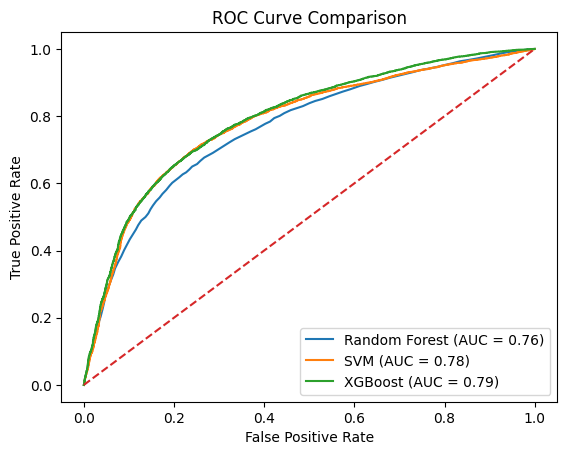

In [22]:
from sklearn.metrics import roc_curve, auc

# Prediction probabilities
rf_probs = rf_model.predict_proba(X_test)[:, 1]
svm_probs = svm_model.decision_function(X_test_scaled)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# ROC curves
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

# AUC scores
auc_rf = auc(fpr_rf, tpr_rf)
auc_svm = auc(fpr_svm, tpr_svm)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot ROC curves
plt.figure()
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.2f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


## Hyperparameter Tuning

Hyperparameter tuning is performed to improve model performance by searching for the best
combination of settings for each algorithm. GridSearchCV is used with cross-validation,
and ROC-AUC is selected as the evaluation metric.


In [23]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score

scoring_metric = "roc_auc"
cv_folds = 3
n_iter_search = 15
n_jobs_value = 2


In [24]:
# Random Forest tuning

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_param_dist = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_dist,
    n_iter=n_iter_search,
    scoring=scoring_metric,
    cv=cv_folds,
    random_state=42,
    n_jobs=n_jobs_value
)

rf_search.fit(X_train, y_train)

print("Best RF Params:", rf_search.best_params_)
print("Best RF CV ROC-AUC:", rf_search.best_score_)


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best RF Params: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}
Best RF CV ROC-AUC: 0.8024836219251684


In [30]:
# Faster SVM tuning

from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV

svm = SVC(kernel="rbf", probability=False, random_state=42)

svm_param_dist = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.01, 0.1]
}

svm_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=svm_param_dist,
    n_iter=5,          # reduced iterations
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1
)

svm_search.fit(X_train_scaled, y_train)

print("Best SVM Params:", svm_search.best_params_)
print("Best SVM CV ROC-AUC:", svm_search.best_score_)

Best SVM Params: {'gamma': 0.01, 'C': 10}
Best SVM CV ROC-AUC: 0.7953868823938298


In [31]:
# XGBoost tuning


from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    tree_method="hist"
)

xgb_param_dist = {
    "n_estimators": [300, 600],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_param_dist,
    n_iter=n_iter_search,
    scoring=scoring_metric,
    cv=cv_folds,
    random_state=42,
    n_jobs=n_jobs_value
)

xgb_search.fit(X_train, y_train)

print("Best XGB Params:", xgb_search.best_params_)
print("Best XGB CV ROC-AUC:", xgb_search.best_score_)


Best XGB Params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
Best XGB CV ROC-AUC: 0.8037394554621698
